In [108]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


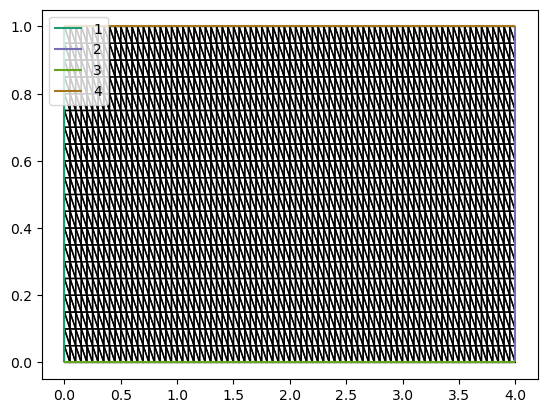

In [109]:
N = 20
mesh = RectangleMesh(4*N, N, 4.0, 1.0)
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [110]:
# Function spaces
V = VectorFunctionSpace(mesh, "P", 2)   # velocity
Q = FunctionSpace(mesh, "P", 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, "P", 1)         # temperature

# Data
mu0 = 1
T0 = 300
n = 1
rho = 1
cp = 1
k = 1
f = Constant((0.,0.))

# Boundary conditions

# Γ1: inflow
# Inflow velocity profile
x = SpatialCoordinate(mesh)
u_in = as_vector((10*x[1]*(1-x[1]), 0.))
bc_U_inflow = DirichletBC(W.sub(0), u_in, 1)
# Inflow temperature
bc_T_inflow = DirichletBC(Z, T0, 1)

# Γ2: outflow
# Homogeneous Neumann for the outflow velocity and temperature
# /

# Γ3, Γ4: bottom and top wall
# No-slip for the velocity: u = 0
bc_U_free = DirichletBC(W.sub(0), Constant((0., 0.)), [3, 4])
# Homogeneous Neumann for the temperature
# /

# Free
bcsU = [bc_U_inflow, bc_U_free]
bcsT = [bc_T_inflow]

In [111]:
# Forms/variational problems for the nonlinear iterations

# viscosity function, given a velocity u and temperature T
def mu_eff(u, T, T0=T0, mu0=mu0, n=n):
  return mu0*exp(T0/T)*(2*inner(sym(grad(u)), sym(grad(u))))**((n-1)/2.0)

def nonlinear_iteration_NS(u, v, p, q, f, Th, u_old):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # u,p   :   TrialFunctions
    # v,q   :   TestFunctions
    # f     :   rhs of NS momentum equation
    # T     :   temperature Function
    # u_old :   advecting velocity Function
    a = 2*mu_eff(u_old, Th)*inner(sym(grad(u)), sym(grad(v)))*dx + rho*inner(dot(grad(u), u_old), v)*dx - div(v)*p*dx + q*div(u)*dx
    L = inner(f, v)*dx
    return a, L

def nonlinear_iteration_thermal(T, eta, rho, cp, k, f, uh, T_old):
    # Implementing fixed-point method for Navier-Stokes equations with thermal source.
    # T     :   TrialFunction
    # eta   :   TestFunction
    # f     :   rhs of thermal equation
    # u     :   advecting velocity Function
    a = k*inner(grad(T), grad(eta))*dx + rho * cp * inner(dot(grad(T), uh), eta)*dx
    L = f*eta*dx + Constant(2)*mu_eff(uh, T_old)*inner(sym(grad(uh)), sym(grad(uh)))*eta*dx
    return a, L

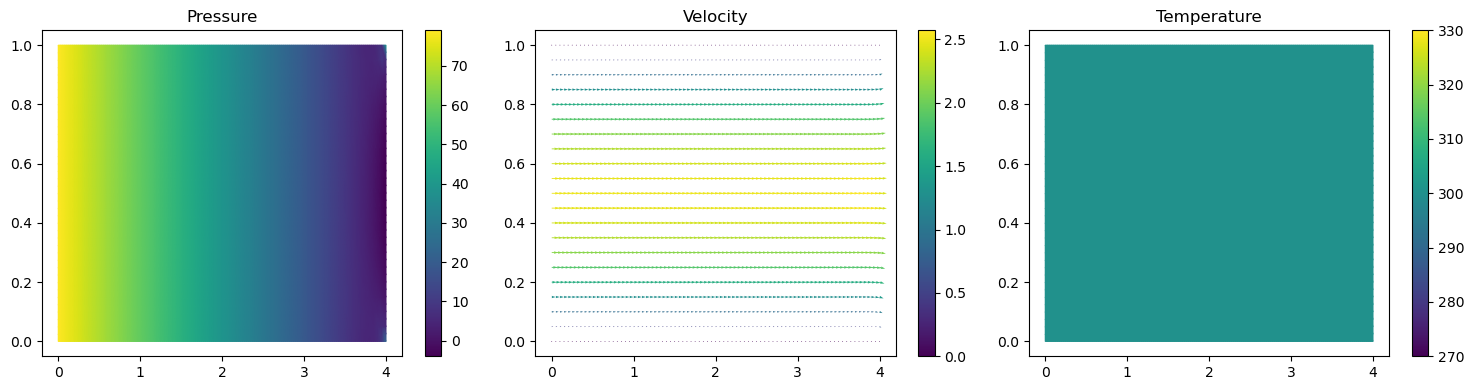

In [112]:
# Initial guess
wh = Function(W)
uh, ph = wh.subfunctions
uh.interpolate(u_in)
Th = Function(Z)
Th.interpolate(T0)

# Initial condition: Stokes problem
uu, pp = TrialFunctions(W)
vv, qq = TestFunctions(W)

# Forms for Stokes problem
a_init = Constant(2*mu0)*inner(sym(grad(uu)), sym(grad(vv)))*dx + - div(vv)*pp*dx + qq*div(uu)*dx
L_init = inner(f, vv)*dx
init_problem = LinearVariationalProblem(a_init, L_init, wh, bcs=bcsU)
solver_init =  LinearVariationalSolver(init_problem)
solver_init.solve()
uh, ph = wh.subfunctions

# Plot the initial guess
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pressure
col1 = tripcolor(ph, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('Pressure')

# Velocity
col2 = quiver(uh, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('Velocity')

# Temperature
col3 = tripcolor(Th, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('Temperature')

plt.tight_layout()
plt.show()

# vtk output for Paraview
outdir = "output/"
outfile = VTKFile(outdir+"solution.pvd")
uh.rename("Velocity")  
ph.rename("Pressure")
Th.rename("Temperature")
outfile.write(uh, ph, Th)

In [113]:
# Nonlinear solver definition: linear variational problem for the Picard iteration

parameters = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}

# Velocity-pressure problem
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)
aU, LU = nonlinear_iteration_NS(u, v, p, q, f, Th, u_old)
pbU = LinearVariationalProblem(aU, LU, wh, bcsU)
solverU =  LinearVariationalSolver(pbU, solver_parameters=parameters)

# Thermal problem
T = TrialFunction(Z)
eta = TestFunction(Z)
T_old = Function(Z)
T_old.assign(Th)
aT, LT = nonlinear_iteration_thermal(T, eta, rho, cp, k, Constant(0.), uh, T_old)
pbT = LinearVariationalProblem(aT, LT, Th, bcsT)
solverT =  LinearVariationalSolver(pbT, solver_parameters=parameters)

In [114]:
maxit = 100
it = 0
tol = 1e-3
err = tol+1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:
    
    it += 1

    solverU.solve()
    uh, ph = wh.subfunctions
    solverT.solve()
    
    err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(Th, T_old, 'H1') / norm(T_old, 'H1')
    
    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    Th.rename("Temperature")
    outfile.write(uh, ph, Th)
    u_old.assign(uh)
    p_old.assign(ph)
    T_old.assign(Th)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: 0.43040232809107853
--------------------------------
Step : 2
Error: 0.07292097540853593
--------------------------------
Step : 3
Error: 0.010200012443361026
--------------------------------
Step : 4
Error: 0.0014135294940975107
--------------------------------
Step : 5
Error: 0.00019197990790894163
--------------------------------
Nonlinear solver converged in 5 iterations.
--------------------------------


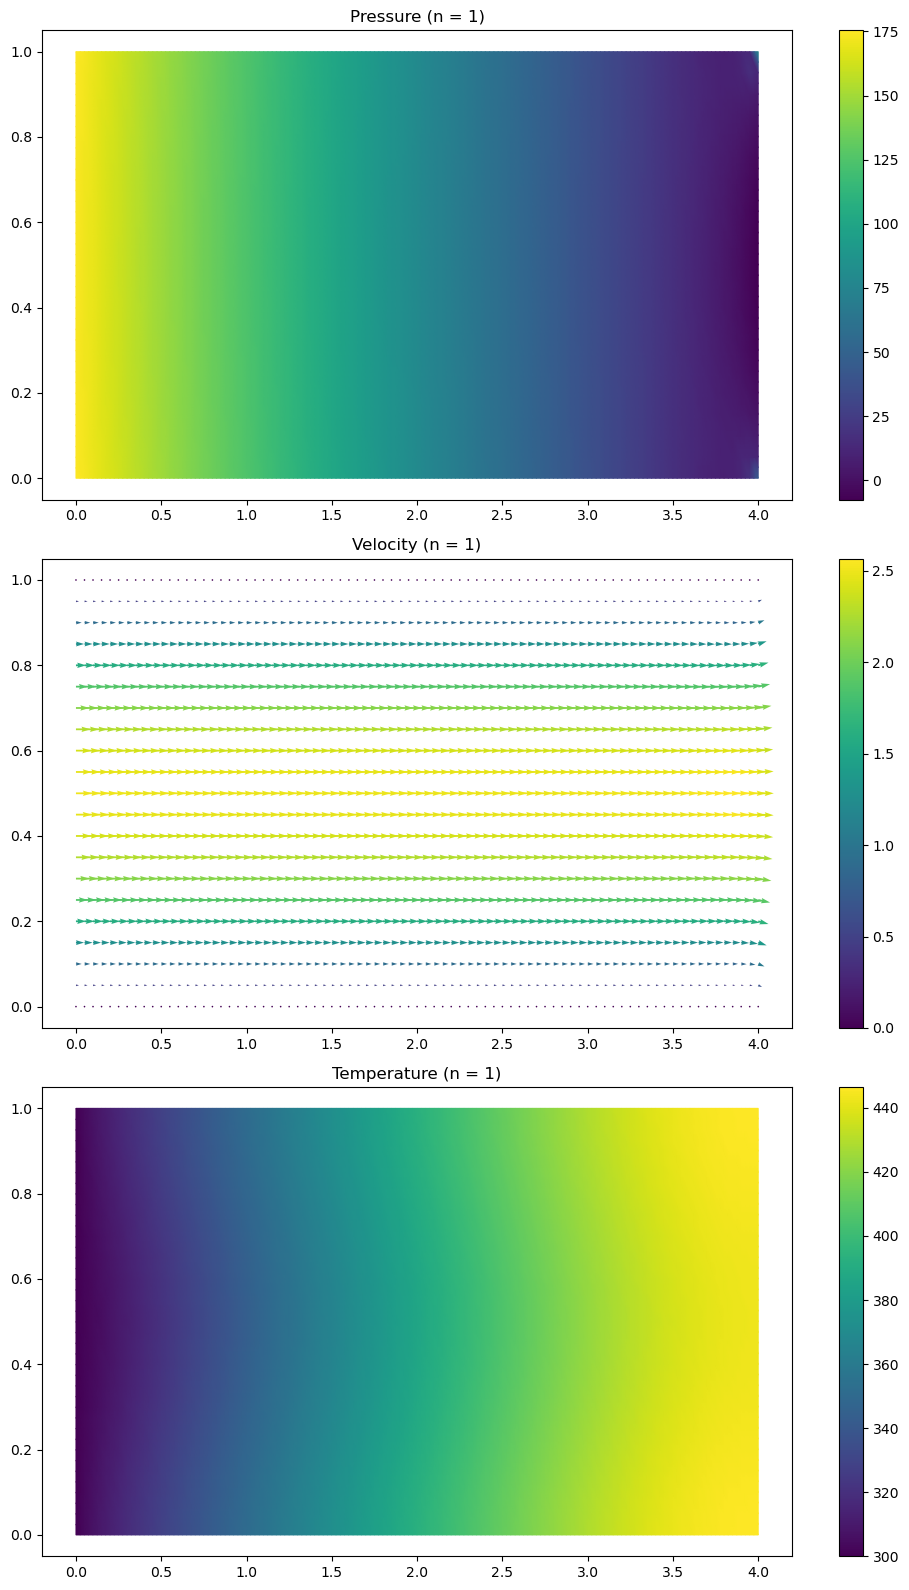

In [115]:
fig, axes = plt.subplots(3, 1, figsize=(10,16))

# Pressure
col1 = tripcolor(ph, axes=axes[0])
fig.colorbar(col1, ax=axes[0])
axes[0].set_title('Pressure (n = '+str(n)+')')

# Velocity
col2 = quiver(uh, axes=axes[1])
fig.colorbar(col2, ax=axes[1])
axes[1].set_title('Velocity (n = '+str(n)+')')

# Temperature
col3 = tripcolor(Th, axes=axes[2])
fig.colorbar(col3, ax=axes[2])
axes[2].set_title('Temperature (n = '+str(n)+')')

plt.tight_layout()
plt.show()

In [116]:
normal = FacetNormal(mesh)
D = sym(grad(uh))
drag3 = assemble(- Constant(2) * mu_eff(uh, Th) * inner(dot(D, normal), Constant((1.0, 0.0)))* ds(3))
drag4 = assemble(- Constant(2) * mu_eff(uh, Th) * inner(dot(D, normal), Constant((1.0, 0.0)))* ds(4))  
print("Drag force on the lower wall for n =", n, ":", drag3)          
print("Drag force on the upper wall for n =", n, ":", drag4)

Drag force on the lower wall for n = 1 : 87.21230505729584
Drag force on the upper wall for n = 1 : 87.45492115910314
